In [39]:
import wbdata
import pandas as pd
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt


In [47]:
countries = ['NGA', 'RWA', 'GHA', 'ZAF', 'SEN','MAR']  # ISO codes for Nigeria, Rwanda, Ghana, South Africa, Senegal, Morocco

indicators = {
    'NY.GDP.PCAP.CD': 'GDP per Capita (USD)',
    'SL.UEM.TOTL.ZS': 'Unemployment Rate (%)',
    'SE.XPD.TOTL.GD.ZS': 'Government Education Expenditure (% of GDP)',
    'SP.DYN.LE00.IN': 'Life Expectancy (Years)',
    'CC.EST':'Control of Corruption',
    'SE.ADT.1524.LT.ZS':'Youth Literacy rate(% of people ages 15-24)',
    'NV.IND.TOTL.ZS':'Industry(% of GDP)',
    'GE.STD.ERR':'Government Effectiveness',
    'EN.POP.SLUM.UR.ZS':'Population living in slums (% of urban population)',
    #'SI.POV.MPUN':'Multidimensional poverty headcount ratio (UNDP) (% of population)',
    'EG.ELC.ACCS.ZS':'Access to electricity (% of population)',
    'EG.ELC.ACCS.RU.ZS':'Access to electricity, rural (% of rural population)',
    'IT.NET.USER.ZS':'Individuals using the Internet (% of population)',
    'DT.ODA.ODAT.XP.ZS':'Net ODA received (% of central government expense)',
    'NE.TRD.GNFS.ZS':'Trade (% of GDP)',
    'NE.EXP.GNFS.CD':'Exports of goods and services (current US$)',
    'NE.EXP.GNFS.ZS':'Exports of goods and services (% of GDP)',
    'NE.IMP.GNFS.ZS':'Imports of goods and services (% of GDP)',
    'BX.KLT.DINV.WD.GD.ZS':'Foreign direct investment (% of GDP)',
    'FP.CPI.TOTL.ZG':'Inflation (annual % growth)',
    'BX.TRF.PWKR.DT.GD.ZS':'Remittances (% of GDP)',
    'TX.VAL.TECH.CD':'High-technology exports (current US$)',
    'SN.ITK.SVFI.ZS':'severe food insecurity (%)',
    'PV.EST':'Political Stability and Absence of Violence: Estimate',
    'RL.EST':'Rule of Law: Estimate',
    'VA.EST':'Voice and Accountability: Estimate',
    'SP.ADO.TFRT':'Adolescent fertility rate (births per 1,000 women ages 15-19)',
    #'SE.TER.CUAT.DO.ZS':'Educational attainment, Doctoral or equivalent, population 25+, total (%) (cumulative)',
    'NV.AGR.TOTL.ZS':'Agriculture, forestry, and fishing, value added (% of GDP)',
    'SP.POP.GROW':'Population growth (annual %)',
    'SL.UEM.1524.NE.ZS':'Youth unemployment(% of total labor force ages 15-24)',
    #'SE.TER.CUAT.BA.ZS':'Educational attainment, at least Bachelors or equivalent, population 25+, total (%) (cumulative)',
    'SE.SEC.CUAT.UP.ZS':'completed upper secondary, population 25+ (cumulative)',
    'SE.PRM.CUAT.ZS':'completed primary, population 25+ (cumulative)',
    'SE.PRM.ENRR':'Primary school enrollment (% gross)',
    'SE.SEC.ENRR':'Secondary school enrollment (% gross)',
    'SP.DYN.IMRT.IN':'Infant Mortality rate (per 1,000 live births)',
    'SH.XPD.CHEX.GD.ZS':'Current health expenditure (% of GDP)',
    'IT.CEL.SETS':'Mobile cellular subscriptions',
    'SP.POP.TOTL':'Population'
}

df = wbdata.get_dataframe(
    indicators,
    country=countries,
    date=(datetime(2013, 1, 1), datetime(2023, 12, 31))
).reset_index()

# Convert 'date' column to datetime (if not already)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Now extract the year
df['year'] = df['date'].dt.year
df.drop(columns='date', inplace=True)

df.head(15)


,country,GDP per Capita (USD),Unemployment Rate (%),Government Education Expenditure (% of GDP),Life Expectancy (Years),Control of Corruption,Youth Literacy rate(% of people ages 15-24),Industry(% of GDP),Government Effectiveness,Population living in slums (% of urban population),...,Youth unemployment(% of total labor force ages 15-24),"completed upper secondary, population 25+ (cumulative)","completed primary, population 25+ (cumulative)",Primary school enrollment (% gross),Secondary school enrollment (% gross),"Infant Mortality rate (per 1,000 live births)",Current health expenditure (% of GDP),Mobile cellular subscriptions,Population,year
0,Ghana,2383.904105,3.063,NaN,65.498,-0.099021,NaN,29.466622,0.197319,NaN,...,NaN,NaN,NaN,NaN,NaN,28.2,NaN,33384500.0,33787914.0,2023
1,Ghana,2229.891226,3.084,2.905294,65.246,-0.064371,85.860001,31.470051,0.203999,33.48685,...,5.191,22.942070,64.894478,96.533157,76.783096,29.2,3.699365,40045300.0,33149152.0,2022
2,Ghana,2445.186625,3.384,3.419494,64.286,-0.128044,NaN,28.405015,0.198514,NaN,...,1.156,NaN,NaN,97.904648,75.313263,30.2,3.860309,40454100.0,32518665.0,2021
3,Ghana,2195.454817,3.313,3.409160,64.309,-0.127223,93.480003,29.876754,0.195798,33.48685,...,NaN,NaN,NaN,96.871811,73.274048,31.4,4.433171,40461600.0,31887809.0,2020
4,Ghana,2186.658227,3.160,3.153071,64.455,-0.108661,NaN,31.107724,0.180279,NaN,...,NaN,NaN,NaN,98.377190,70.607887,32.6,3.254505,40857100.0,31258945.0,2019
5,Ghana,2195.321660,3.253,3.015956,64.138,-0.138364,NaN,31.177744,0.169758,33.48685,...,NaN,NaN,NaN,97.315117,67.753822,33.9,2.430012,40934900.0,30637585.0,2018
6,Ghana,2012.286626,3.369,3.186117,63.829,-0.253390,87.782181,29.952218,0.171892,NaN,...,6.227,15.598560,58.186501,99.050072,66.381920,35.1,2.687870,36751800.0,30008354.0,2017
7,Ghana,1912.479913,5.232,3.454744,63.522,-0.175534,NaN,27.693255,0.167195,33.48685,...,NaN,NaN,NaN,100.415701,67.157892,36.4,3.390358,38305100.0,29356742.0,2016
8,Ghana,1722.772828,6.806,3.688745,63.175,-0.210838,NaN,31.119380,0.167895,NaN,...,15.177,22.084148,51.817280,102.015853,67.082587,37.7,4.542968,35008400.0,28696068.0,2015
9,Ghana,1949.908329,4.415,3.682348,62.832,-0.195330,87.599998,33.898203,0.174501,36.84704,...,NaN,NaN,NaN,97.893625,63.585449,39.1,4.016441,30360800.0,28041592.0,2014


In [48]:
print(df.info())

<class 'wbdata.client.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 39 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   country                                                        66 non-null     object 
 1   GDP per Capita (USD)                                           66 non-null     float64
 2   Unemployment Rate (%)                                          66 non-null     float64
 3   Government Education Expenditure (% of GDP)                    62 non-null     float64
 4   Life Expectancy (Years)                                        66 non-null     float64
 5   Control of Corruption                                          66 non-null     float64
 6   Youth Literacy rate(% of people ages 15-24)                    28 non-null     float64
 7   Industry(% of GDP)                                             66 no

In [49]:
print(df.iloc[:,19:].info())

<class 'wbdata.client.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 20 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Inflation (annual % growth)                                    66 non-null     float64
 1   Remittances (% of GDP)                                         66 non-null     float64
 2   High-technology exports (current US$)                          62 non-null     float64
 3   severe food insecurity (%)                                     29 non-null     float64
 4   Political Stability and Absence of Violence: Estimate          66 non-null     float64
 5   Rule of Law: Estimate                                          66 non-null     float64
 6   Voice and Accountability: Estimate                             66 non-null     float64
 7   Adolescent fertility rate (births per 1,000 women ages 15-19)  66 no

In [50]:
df.shape

(66, 39)

In [51]:
missing_summary = df.isnull().mean().sort_values(ascending=False)
missing_summary = (missing_summary * 100).round(1)
print(missing_summary[missing_summary > 0])


Youth Literacy rate(% of people ages 15-24)               57.6
severe food insecurity (%)                                56.1
Population living in slums (% of urban population)        54.5
completed upper secondary, population 25+ (cumulative)    43.9
completed primary, population 25+ (cumulative)            43.9
Youth unemployment(% of total labor force ages 15-24)     34.8
Net ODA received (% of central government expense)        28.8
Secondary school enrollment (% gross)                     22.7
Imports of goods and services (% of GDP)                  16.7
Exports of goods and services (% of GDP)                  16.7
Trade (% of GDP)                                          16.7
Exports of goods and services (current US$)               16.7
Current health expenditure (% of GDP)                      9.1
Primary school enrollment (% gross)                        7.6
Government Education Expenditure (% of GDP)                6.1
High-technology exports (current US$)                  

In [52]:
# Sort values to ensure interpolation happens in order
df = df.sort_values(by=['country', 'year'])

# Group by country and interpolate numeric features
df_imputed = df.copy()
for col in df.columns:
    if df[col].dtype in ['float64', 'int64'] and col not in ['year']:
        df_imputed[col] = df.groupby('country')[col].transform(lambda group: group.interpolate(method='linear', limit_direction='both'))

# Optional: Forward fill as backup for remaining gaps
df_imputed.fillna(method='ffill', inplace=True)
df_imputed.fillna(method='bfill', inplace=True)


C:\Users\Godwin\AppData\Local\Temp\ipykernel_33592\2194464113.py:11: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

C:\Users\Godwin\AppData\Local\Temp\ipykernel_33592\2194464113.py:12: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [53]:
df_imputed.info()

<class 'wbdata.client.DataFrame'>
Index: 66 entries, 10 to 55
Data columns (total 39 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   country                                                        66 non-null     object 
 1   GDP per Capita (USD)                                           66 non-null     float64
 2   Unemployment Rate (%)                                          66 non-null     float64
 3   Government Education Expenditure (% of GDP)                    66 non-null     float64
 4   Life Expectancy (Years)                                        66 non-null     float64
 5   Control of Corruption                                          66 non-null     float64
 6   Youth Literacy rate(% of people ages 15-24)                    66 non-null     float64
 7   Industry(% of GDP)                                             66 non-nu

In [54]:
df_imputed.iloc[:,19:].info()

<class 'wbdata.client.DataFrame'>
Index: 66 entries, 10 to 55
Data columns (total 20 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Inflation (annual % growth)                                    66 non-null     float64
 1   Remittances (% of GDP)                                         66 non-null     float64
 2   High-technology exports (current US$)                          66 non-null     float64
 3   severe food insecurity (%)                                     66 non-null     float64
 4   Political Stability and Absence of Violence: Estimate          66 non-null     float64
 5   Rule of Law: Estimate                                          66 non-null     float64
 6   Voice and Accountability: Estimate                             66 non-null     float64
 7   Adolescent fertility rate (births per 1,000 women ages 15-19)  66 non-nu

In [56]:
df_imputed['GDP'] =df_imputed['GDP per Capita (USD)']  * df_imputed['Population']

In [57]:
fig = px.line(
    df_imputed,
    x='year',
    y='GDP per Capita (USD)',
    color='country',
    title='GDP per Capita (2013–2023)',
    markers=True
)
#fig.add_vline(x=2008, line_dash='dash', line_color='red', annotation_text='2008 Crisis')
fig.add_vline(x=2020, line_dash='dash', line_color='red', annotation_text='COVID-19')

fig.update_layout(yaxis_title='GDP per Capita (USD)')
fig.show()


In [58]:
# Filter for one country, e.g., Nigeria
df_country = df_imputed[df_imputed['country'] == 'Nigeria']

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_country['year'],
    y=df_country['GDP per Capita (USD)'],
    name='GDP per Capita',
    yaxis='y1',
    mode='lines+markers'
))

fig.add_trace(go.Scatter(
    x=df_country['year'],
    y=df_country['Remittances (% of GDP)'],
    name='Remittances ',
    yaxis='y2',
    mode='lines+markers'
))

fig.update_layout(
    title='GDP vs Remittances – Nigeria',
    xaxis=dict(title='Year'),
    yaxis=dict(title='GDP per Capita', side='left'),
    yaxis2=dict(title='Remittances', overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99)
)
#fig.add_vline(x=2008, line_dash='dash', line_color='red', annotation_text='2008 Crisis')
fig.add_vline(x=2020, line_dash='dash', line_color='red', annotation_text='COVID-19')

fig.show()


In [59]:
# Calculate correlation (excluding year and country)
corr_data = df_imputed[['GDP per Capita (USD)', 'Unemployment Rate (%)', 'Remittances (% of GDP)', 'Inflation (annual % growth)']].dropna()
corr = corr_data.corr()



In [60]:
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu',
    title='Correlation Heatmap – Economic Indicators'
)
fig.show()


In [61]:
fig = px.line(
    df_imputed,
    x='year',
    y='GDP per Capita (USD)',
    color='country',
    facet_col='country',
    facet_col_wrap=3
)
fig.show()


## **Theme 2: Education & Human Capital**

In [62]:
fig = px.line(
    df_imputed,
    x='year',
    y='Government Education Expenditure (% of GDP)',
    color='country',
    title='Government Expenditure on Education (% of GDP)',
    markers=True
)
#fig.add_vline(x=2008, line_dash='dash', line_color='red', annotation_text='2008 Crisis')
fig.add_vline(x=2020, line_dash='dash', line_color='red', annotation_text='COVID-19')
fig.update_layout(yaxis_title='% of GDP')
fig.show()


In [63]:
df_country = df_imputed[df_imputed['country'] == 'Rwanda']

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_country['year'],
    y=df_country['Government Education Expenditure (% of GDP)'],
    name='Education Expenditure (% of GDP)',
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=df_country['year'],
    y=df_country['Youth Literacy rate(% of people ages 15-24)'],
    name='Youth Literacy Rate (%)',
    yaxis='y2'
))

fig.update_layout(
    title='Education Spending vs Literacy – Rwanda',
    xaxis=dict(title='Year'),
    yaxis=dict(title='Expenditure (% of GDP)', side='left'),
    yaxis2=dict(title='Literacy Rate (%)', overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99)
)
fig.show()


In [64]:
df_bar = df_imputed.melt(
    id_vars=['year', 'country'],
    value_vars=['completed primary, population 25+ (cumulative)','completed upper secondary, population 25+ (cumulative)'],
    var_name='Education Level',
    value_name='Education completion Rate (%)'
)

fig = px.bar(
    df_bar[df_bar['year'] == 2023],
    x='country',
    y='Education completion Rate (%)',
    color='Education Level',
    barmode='group',
    title='School Enrollment Rates (2023)'
)
fig.show()


In [65]:
# Melt the DataFrame to long format
df_bar2 = df_imputed.melt(
    id_vars=['year', 'country'],
    value_vars=['Government Education Expenditure (% of GDP)', 'Unemployment Rate (%)'],
    var_name='Indicator',
    value_name='Value'
)

# Filter for the year 2023
df_plot = df_bar2[df_bar2['year'] == 2023]

# Create grouped bar chart
fig = px.bar(
    df_plot,
    x='country',
    y='Value',
    color='Indicator',
    barmode='group',
    title='Unemployment Rate and Government Education Expenditure (% of GDP) – 2023'
)

fig.show()


In [66]:
corr_vars = ['GDP per Capita (USD)', 'Unemployment Rate (%)', 'Government Education Expenditure (% of GDP)',
             'Youth Literacy rate(% of people ages 15-24)', 'Primary school enrollment (% gross)', 'Secondary school enrollment (% gross)']

corr_matrix = df[corr_vars].dropna().corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='YlGnBu',
    title='Correlation: Education & Economy'
)
fig.show()


## **Theme 3: Health vs. Wealth**

In [67]:
fig = px.line(
    df_imputed,
    x='year',
    y='Life Expectancy (Years)',
    color='country',
    title='Life Expectancy at Birth (2013–2023)',
    markers=True
)
#fig.add_vline(x=2008, line_dash='dash', line_color='red', annotation_text='2008 Crisis')
fig.add_vline(x=2020, line_dash='dash', line_color='red', annotation_text='COVID-19')
fig.update_layout(yaxis_title='Years')
fig.show()
fig.write_image("life_expectancy.svg")


In [68]:
df_2020 = df_imputed[df_imputed['year'] == 2023]

fig = px.scatter(
    df_2020,
    x='GDP per Capita (USD)',
    y='Life Expectancy (Years)',
    color='country',
    size='Current health expenditure (% of GDP)',
    hover_name='country',
    title='Health vs. Wealth (2023)',
    size_max=60,
    #log_x=True  # Optional for clearer GDP axis
)
fig.update_layout(xaxis_title='GDP per Capita ', yaxis_title='Life Expectancy (years)')
fig.show()
fig.write_image("health_vs_wealth.svg", width=800, height=600)

In [69]:
df_country = df_imputed[df_imputed['country'] == 'Morocco']

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_country['year'],
    y=df_country['Current health expenditure (% of GDP)'],
    name='Health Expenditure per Capita (USD)',
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=df_country['year'],
    y=df_country['Infant Mortality rate (per 1,000 live births)'],
    name='Infant Mortality Rate (per 1,000)',
    yaxis='y2'
))

fig.update_layout(
    title='Health Spending vs. Child Mortality – Morocco',
    xaxis=dict(title='Year'),
    yaxis=dict(title='Health Expenditure (% of GDP)', side='left'),
    yaxis2=dict(title='Infant Mortality Rate', overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99)
)
fig.show()
fig.write_image("health_vs_child_mortality.svg", width=800, height=600)


In [70]:
corr_vars = [
    'GDP per Capita (USD)', 'Life Expectancy (Years)', 'Infant Mortality rate (per 1,000 live births)',
    'Current health expenditure (% of GDP)', 'Government Education Expenditure (% of GDP)'
]

corr_matrix = df_imputed[corr_vars].dropna().corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title='Correlation: Health vs. Wealth'
)
fig.show()


## **THEME 4: Technology, Trade & Education**

In [80]:
#Education Attainment vs Internet Use
country = 'Nigeria'
df_country = df_imputed[df_imputed['country'] == country]

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_country['year'], y=df_country['completed upper secondary, population 25+ (cumulative)'],
                         name='Completed Upper Secondary', mode='lines+markers'))
fig.add_trace(go.Scatter(x=df_country['year'], y=df_country['Individuals using the Internet (% of population)'],
                         name='Internet Usage (% of population)', mode='lines+markers', yaxis='y2'))

fig.update_layout(
    title=f"Education vs Internet Usage in {country}",
    xaxis_title='Year',
    yaxis=dict(title='Completed Upper Secondary (%)'),
    yaxis2=dict(title='Internet Usage (%)', overlaying='y', side='right'),
)
fig.show()
fig.write_image("education_vs_internet.svg", width=800, height=600)

In [81]:
# High-tech Exports vs Trade (% of GDP)
df_imputed['High-tech exports (% of GDP)'] = (
    df_imputed['High-technology exports (current US$)'] / df_imputed['GDP']) * 100

latest_year = df_imputed['year'].max()
df_latest = df_imputed[df_imputed['year'] == latest_year]

fig = px.scatter(df_latest,
                 x='Trade (% of GDP)',
                 y='High-tech exports (% of GDP)',
                 color='country',
                 size='Individuals using the Internet (% of population)',
                 hover_name='country',
                 title=f'High-tech Exports vs Trade (% of GDP) - {latest_year}',
                 labels={'Trade': 'Trade (% of GDP)', 'High-tech exports': 'High-tech exports (% of GDP)'})
fig.show()
fig.write_image("high_tech_exports_vs_trade.svg", width=800, height=600)

In [82]:
#Area Chart: Sectoral Composition Over Time
df_sector = df_country.copy()
df_sector['High-tech exports (% of GDP)'] = (
    df_sector['High-technology exports (current US$)'] / df_sector['GDP']) * 100

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_sector['year'], y=df_sector['Agriculture, forestry, and fishing, value added (% of GDP)'], name='Agriculture', stackgroup='one'))
fig.add_trace(go.Scatter(x=df_sector['year'], y=df_sector['Industry(% of GDP)'], name='Industry', stackgroup='one'))
fig.add_trace(go.Scatter(x=df_sector['year'], y=df_sector['High-tech exports (% of GDP)'], name='Tech GDP', stackgroup='one'))

fig.update_layout(title=f'Sectoral Composition Over Time - {country}',
                  xaxis_title='Year',
                  yaxis_title='Percent of GDP',
                  )
fig.show()
fig.write_image("sectoral_composition.svg", width=800, height=600)

## **THEME 5: Governance & Institutional Quality**

In [88]:
#Radar Chart – Governance Profiles
governance_cols = [
    'Political Stability and Absence of Violence: Estimate',
    'Rule of Law: Estimate',
    'Voice and Accountability: Estimate',
    'Government Effectiveness',
    'Control of Corruption',
    'Youth Literacy rate(% of people ages 15-24)'
]

# Optional: rename for shorter plot labels
df_imputed_renamed = df_imputed.rename(columns={
    'Political Stability and Absence of Violence: Estimate': 'Stability',
    'Rule of Law: Estimate': 'Rule of Law',
    'Voice and Accountability: Estimate': 'Voice',
    'Government Effectiveness': 'Effectiveness',
    'Control of Corruption': 'Corruption',
    'Youth Literacy rate(% of people ages 15-24)': 'Youth Literacy Rate'
})


In [92]:
# Select latest year data (e.g., 2023)
df_radar = df_imputed_renamed[df_imputed_renamed['year'] == 2023]
df_radar = df_radar[['country', 'Stability', 'Rule of Law', 'Voice', 'Effectiveness', 'Corruption']]

# Normalize values (0–1) for comparison
df_radar_norm = df_radar.copy()
indicators = df_radar.columns[1:]
df_radar_norm[indicators] = df_radar[indicators].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# Reshape for radar chart
df_radar_melted = df_radar_norm.melt(id_vars='country', var_name='Indicator', value_name='Score')

fig = px.line_polar(
    df_radar_melted,
    r='Score',
    theta='Indicator',
    color='country',
    line_close=True,
    title='Governance Profiles (2023)',
    template='plotly_dark'
)
fig.show()
fig.write_image("governance_profiles.svg", width=800, height=600)


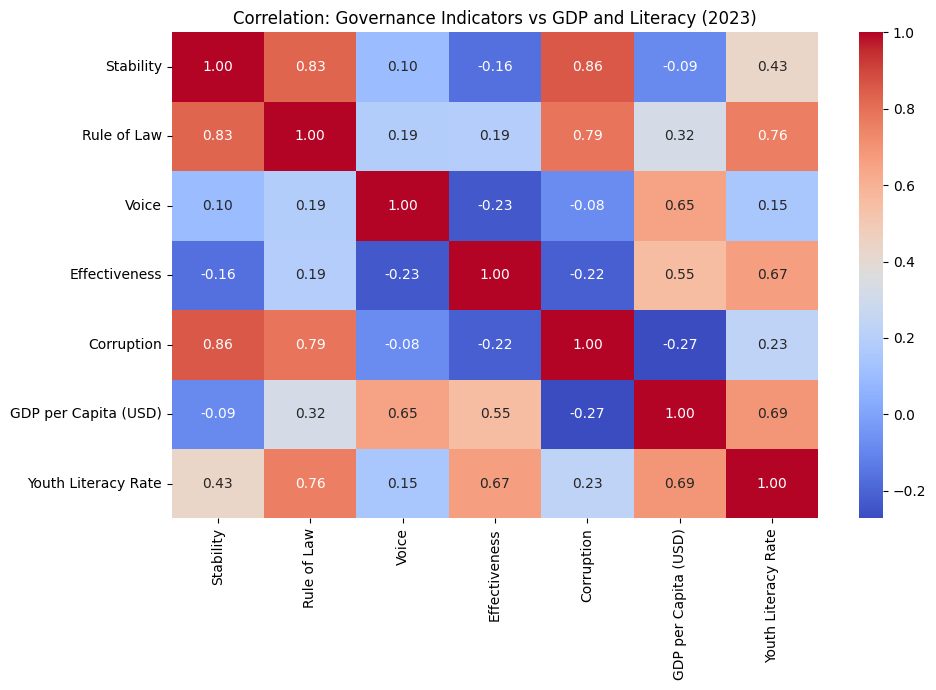

In [90]:

# Select correlation columns
corr_cols = ['Stability', 'Rule of Law', 'Voice', 'Effectiveness', 'Corruption', 
             'GDP per Capita (USD)', 'Youth Literacy Rate']

df_corr = df_imputed_renamed[df_imputed_renamed['year'] == 2023][corr_cols].dropna()

# Compute correlation
corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Governance Indicators vs GDP and Literacy (2023)')
plt.tight_layout()
plt.show()


In [93]:

df_bar = df_imputed_renamed[df_imputed_renamed['year'] == 2023][['country', 'Corruption', 'Foreign direct investment (% of GDP)']]
df_bar = df_bar.dropna()

fig = px.bar(
    df_bar,
    x='country',
    y='Foreign direct investment (% of GDP)',
    color='Corruption',
    title='FDI vs Control of Corruption (2023)',
    labels={'Corruption': 'Control of Corruption'},
    color_continuous_scale='Viridis'
)
fig.show()
fig.write_image("fdi_vs_corruption.svg", width=800, height=600)